In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import M_sun, G, c
from scipy.constants import pi

from mpmath import hyp1f1

from astropy.constants import M_sun

In [8]:
def F_pml(t, h, y, M_lens):

    from astropy.constants import M_sun, G, c
    from scipy.constants import pi
    from mpmath import hyp1f1
    from numpy import exp, conj


    # values
    N = len(t)
    Rs = 2 * (M_lens*M_sun.value) * G.value / c.value**2
    tM = 2 * Rs / c.value

    # frequency
    freqs = np.fft.fftfreq(N, d=t[1]-t[0])

    # angular frequency
    omega = 2 * pi * freqs

    # dimensionless frequency
    nu = (tM / (2 * pi)) * omega

    # amplification factor
    F = np.empty(N, dtype=complex)

    # set zero-component 
    F[0] = 1.0 + 0.0j

    # index range parameter
    k_max = N // 2

    # calculate amplification factor
    for k in range(1, k_max + 1):

        w = nu[k]

        if w <= 0:
            F[k] = 1.0 + 0.0j
            continue

        a = 1.0j * pi * w
        b = 1.0
        z = 1.0j * pi * w * y**2

        try:
            hyp = complex(hyp1f1(a,b,z))
        except Exception as exc:
            hyp = 1.0 + 0.0j

        A_num = (2 * pi **2) * w
        A_den = 1 - exp(-2 * (pi**2) * w)

        A = (A_num/A_den)**(1/2)

        F[k] = A * hyp 

    if N % 2 == 0:
        F[k_max] = F[k_max].real + 0.0j
        
    for k in range(1 + k_max + 1):
        F[-k] = conj(F[k]) 

    return F, nu
                              

In [3]:
# signal parameters
t = np.linspace(0,0.02,10000)
M_lens = 250 * M_sun.value
h0 = 1.0                                        # maximum amplitude
nu0 = 5/4                                       # Fresnel number
y = 0.1                                         # source position
M_source = 0.24 * M_lens / nu0                                                 
f0 = 1.207*10**(4)*(M_sun.value/M_source)
Gamma = 1.496 * f0
omega0 = 2*pi*f0
h = h0 * np.exp(-Gamma*t)*np.cos(omega0 * t)

(0.1, 10)

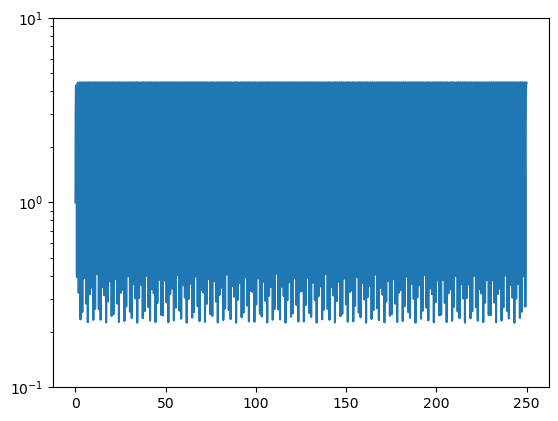

In [ ]:
N = len(t)
freqs = np.fft.fftfreq(N, d=t[1]-t[0])
freqs_shifted = np.fft.fftshift(freqs)

F, nu = F_pml(t=t, h=h, y=y, M_lens=250)
F_shifted = np.fft.fftshift(F)
nu_shifted = np.fft.fftshift(nu)

plt.plot(freqs_shifted[N//2:]*(10**(-3)), np.abs(F_shifted[N//2:]))
plt.yscale('log')
plt.xlim([0,50])
plt.ylim([0.1,10])

(0.0, 0.1)

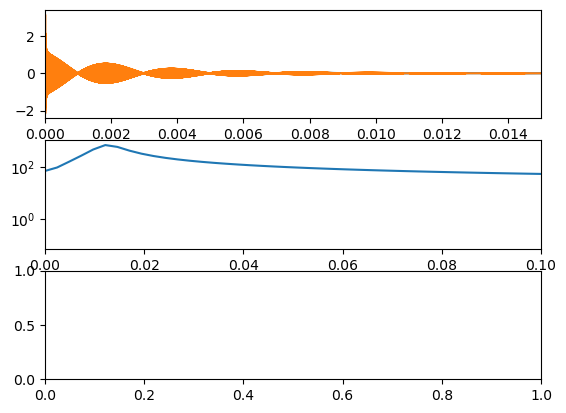

In [ ]:
fig, ax = plt.subplots(nrows=3)

hL = np.fft.ifft(hL_shifted)

ax[0].plot(t,h)
ax[0].plot(t, np.fft.ifft(hL_shifted).real)
ax[0].set_xlim([0,0.015])

ax[1].plot(nu_shifted[len(nu_shifted)//2:]*10**-3, np.abs(hL_shifted[len(nu_shifted)//2:]))
ax[1].set_yscale('log')
#ax[1].set_xscale('log')
ax[1].set_xlim([0,0.1])

#ax[2].plot(nu_shifted, F_shifted)
